In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [5]:
from collections import deque
from glob import glob
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import os
import pandas as pd
import plotly.express as px
import re
import tifffile as tf
import torch

import sys
sys.path.insert(0,'..')
from data_prep import draw, load, generate, tree
from neurotrack.data import neuron_data

In [3]:
inference_output_files = os.listdir(os.path.expanduser('~/data/neurotrack_data/inference_outputs/neuromorpho_with_artifacts_inference_output'))
neuromorpho_images_root = os.path.expanduser("~/data/neurotrack_data/simulated_neurons/neuromorpho/neuromorpho_with_artifacts_test_set")
neuromorpho_images = [f for x in os.walk(neuromorpho_images_root) for f in glob(os.path.join(x[0], '*_image.tif'))]
fnames = [f.split(f'_06-20-25_inference.npz')[0] for f in inference_output_files]


In [4]:
fname = fnames[0]
matching_inference_data = [os.path.join(os.path.expanduser('~/data/neurotrack_data/inference_outputs/neuromorpho_with_artifacts_inference_output'),f) for f in inference_output_files if f.split('_06-20-25_inference.npz')[0] == fname][0]
matching_image = [f for f in neuromorpho_images if f.split('/')[-1].split('_image.tif')[0] == fname][0]

# Load the image
tif_img = tf.imread(matching_image)
print(f"Image shape: {tif_img.shape}")
# Load the reconstructed paths
paths = np.load(matching_inference_data, allow_pickle=True)['paths']
paths = [torch.tensor(path) for path in paths if not isinstance(path, torch.Tensor)]

Image shape: (3, 233, 651, 314)


In [5]:
def split_paths_into_sections(paths):
    """
    Splits paths into sections based on their origins.
    Each section is defined as a segment of the path between intersections with other paths' origins.
    """
    path_origins = np.array([p[0][:3] for p in paths])
    sections = {}
    # divide each path wherever it intersects with the origin of other paths
    # create a new section for each segment of the path
    for path in paths:
        intersections = [0] + [i+1 for i, point in enumerate(path[1:]) if point[:3] in path_origins]
        if len(intersections) > 1:
            sections |= {len(sections) + i: path[intersections[i]:intersections[i+1]+1] for i in range(len(intersections)-1)}
            if intersections[-1] != len(path) - 1:
                sections[len(sections)] = path[intersections[-1]:]  # Add the last segment
        else:
            sections[len(sections)] = path

    return sections


def get_single_stream_length(section_id, section_graph, sections, visited=None):
    """
    Recursively calculates the total length of a section and its downstream sections.
    Prevents infinite recursion by tracking visited sections.
    """
    if visited is None:
        visited = set()
    if section_id in visited:
        return 0
    visited.add(section_id)
    # total_length = len(sections[section_id])
    # total_length = np.linalg.norm(sections[section_id][0,:3] - sections[section_id][-1,:3])
    total_length = (torch.sum((sections[section_id][1:, :3] - sections[section_id][:-1, :3])**2, dim=1)**0.5).sum()
    for connected_section in section_graph.get(section_id, []):
        total_length += get_single_stream_length(connected_section, section_graph, sections, visited)
    return total_length


def get_all_stream_lengths(sections):
    """
    Calculate the lengths of each section.
    """
    # Make section adjacency graph
    section_graph = {}
    for id,section in sections.items():
        section_graph[id] = []
        for other_id,other_section in sections.items():
            if id != other_id and all(section[-1] == other_section[0]):
                section_graph[id].append(other_id)
    # Calculate total length of each section and its downstream sections
    stream_lengths = {}
    for section_id in sections.keys():
        stream_lengths[section_id] = get_single_stream_length(section_id, section_graph, sections)

    return stream_lengths, section_graph


def get_longest_stream(section_id, section_graph, section_lengths):
    """
    Get longest stream, starting at the given section id, where a stream is a list of section ids of consecutive sections.
    """
    stream = [section_id]
    while section_id in section_graph:
        next_section = max(section_graph[section_id], key=lambda x: section_lengths.get(x, 0), default=None)
        if next_section is not None:
            stream.append(next_section)
            section_id = next_section
        else:
            break
    return stream


def get_hierarchical_streams(stream_lengths, section_graph):

    hierarchical_streams = {}
    # list all sections in descending order of their stream lengths
    section_ids_sorted = sorted(stream_lengths.keys(), key=lambda x: stream_lengths[x], reverse=True)
    # start with the longest stream
    while section_ids_sorted:
        hierarchical_streams[section_ids_sorted[0]] = get_longest_stream(section_ids_sorted[0], section_graph, stream_lengths)
        # remove the sections that have been collected into a stream
        for section in hierarchical_streams[section_ids_sorted[0]]:
            if section in section_ids_sorted:
                section_ids_sorted.remove(section)
    
    return hierarchical_streams

def restitch_sections(hierarchical_streams, sections):
    restitched_sections = {}
    for i in hierarchical_streams.keys():
        restitched_section = np.concatenate([sections[section_id] for section_id in hierarchical_streams[i]])
        # remove duplicate points, keep order of first occurrence
        restitched_section, indices = np.unique(restitched_section, axis=0, return_index=True)
        order = np.argsort(indices)
        restitched_section = restitched_section[order]
        restitched_sections[i] = restitched_section
    
    return restitched_sections

In [ ]:
sections = split_paths_into_sections(paths)
stream_lengths, section_graph = get_all_stream_lengths(sections)
hierarchical_streams = get_hierarchical_streams(stream_lengths, section_graph)
restitched_sections = restitch_sections(hierarchical_streams, sections)


# # Glue sections together into streams based on their lengths
# streams = {}
# # list all sections in descending order of their lengths
# section_ids_sorted = sorted(stream_lengths.keys(), key=lambda x: stream_lengths[x], reverse=True)
# # start with the longest stream
# while section_ids_sorted:
#     streams[section_ids_sorted[0]] = get_longest_stream(section_ids_sorted[0], section_graph, stream_lengths)
#     # remove the sections that have been glued together
#     for section in streams[section_ids_sorted[0]]:
#         if section in section_ids_sorted:
#             section_ids_sorted.remove(section)

# # restitched_sections = {i: np.concatenate([sections[section_id] for section_id in streams[i]]) for i in streams.keys()}
# restitched_sections = {}
# for i in streams.keys():
#     restitched_section = np.concatenate([sections[section_id] for section_id in streams[i]])
#     # remove duplicate points, keep order of first occurrence
#     restitched_section, indices = np.unique(restitched_section, axis=0, return_index=True)
#     order = np.argsort(indices)
#     restitched_section = restitched_section[order]
#     restitched_sections[i] = restitched_section

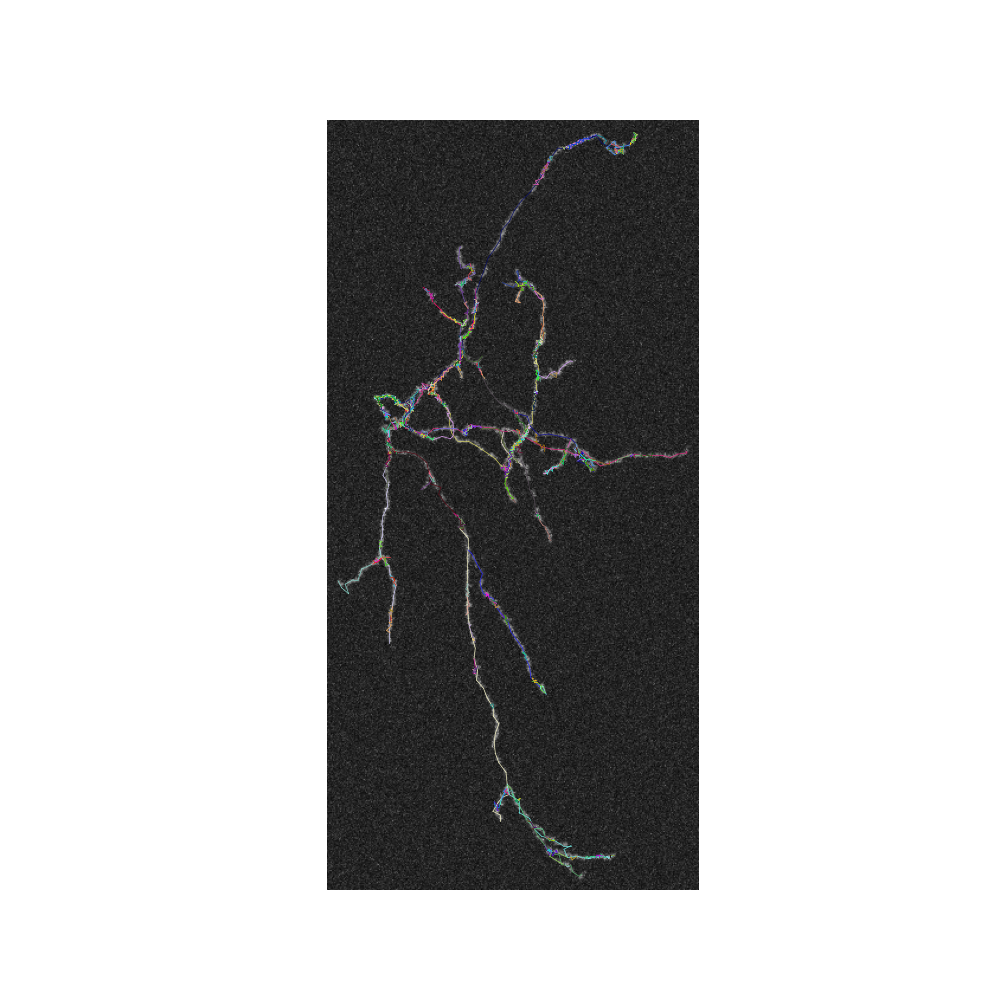

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(tif_img.transpose(1,2,3,0).max(0)[...,0], cmap='gray')
ax.set_axis_off()

for path in paths:
    c = np.random.rand(3)
    # Draw lines between consecutive points in the path
    for j in range(len(path) - 1):
        y0, x0 = int(np.round(path[j][1])), int(np.round(path[j][2]))
        y1, x1 = int(np.round(path[j+1][1])), int(np.round(path[j+1][2]))
        ax.plot([x0,x1], [y0, y1], color=c, linewidth=0.5)

In [8]:
new_streams = [restitched_sections[i] for i in restitched_sections.keys()]

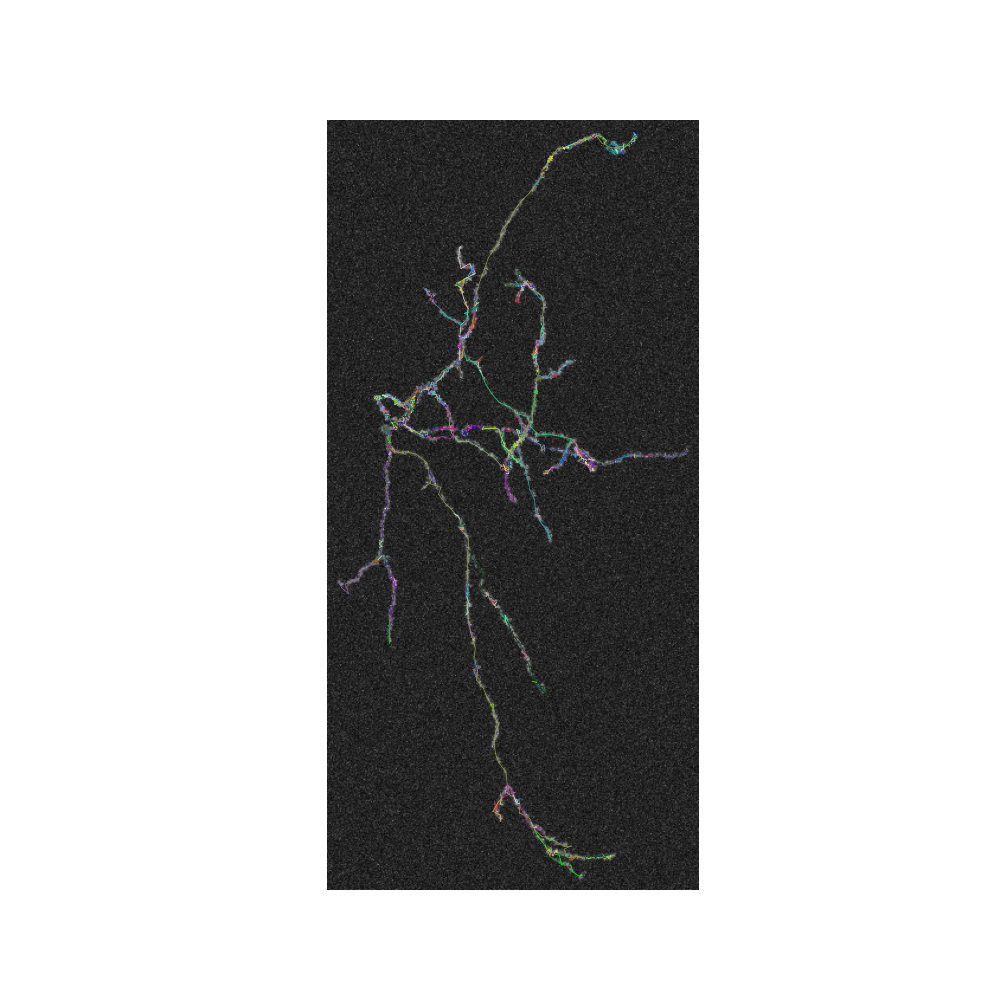

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(tif_img.transpose(1,2,3,0).max(0)[..., 0], cmap='gray')
ax.set_axis_off()

for path in new_streams:
    c = np.random.rand(3)
    # Draw lines between consecutive points in the path
    for j in range(len(path) - 1):
        y0, x0 = int(np.round(path[j][1])), int(np.round(path[j][2]))
        y1, x1 = int(np.round(path[j+1][1])), int(np.round(path[j+1][2]))
        ax.plot([x0,x1], [y0, y1], color=c, linewidth=0.5)

In [10]:
# new_streams_trimmed = [p for p in new_streams if np.linalg.norm(p[0,:3]-p[-1,:3]) > 30.0]
new_streams_trimmed = [p for p in new_streams if (np.sum((p[1:, :3] - p[:-1, :3])**2, 1)**0.5).sum() > 100.0]

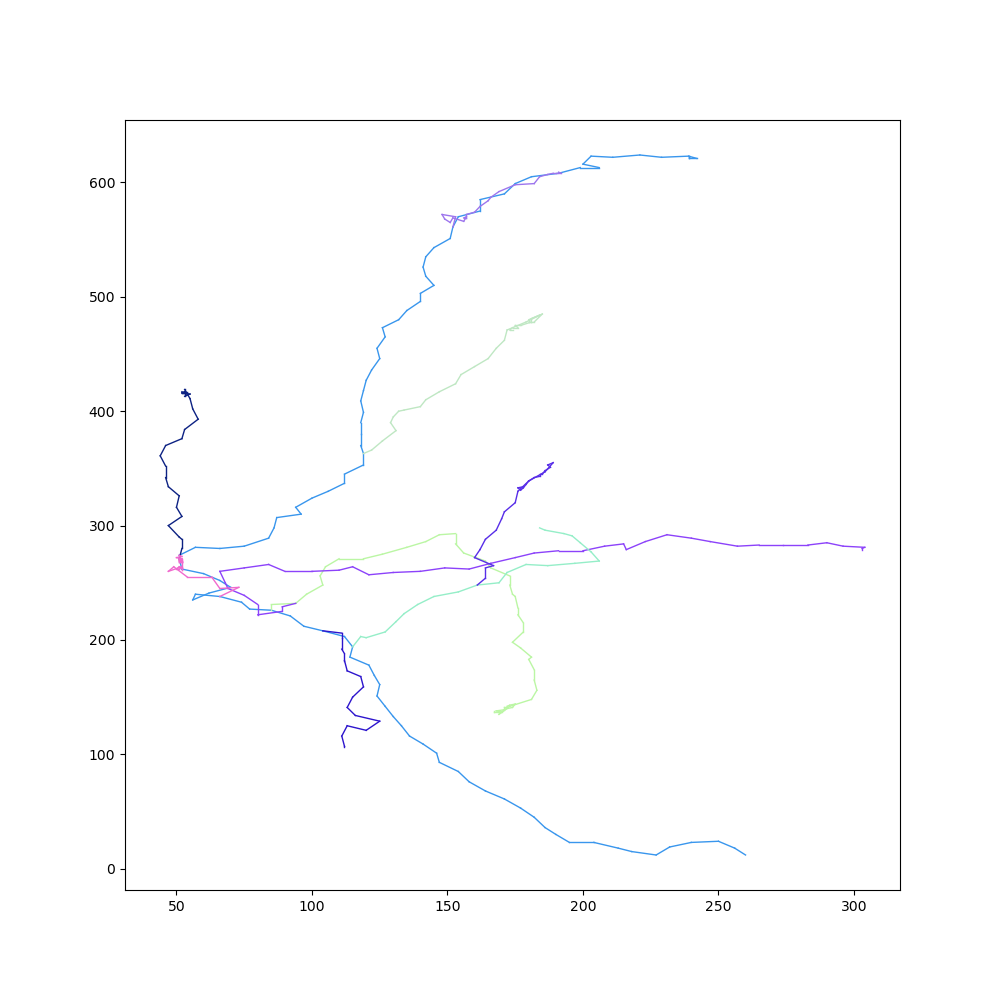

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
# ax.imshow(tif_img.transpose(1,2,3,0).max(0)[..., 0], cmap='gray')
# ax.set_axis_off()

for path in new_streams_trimmed:
    c = np.random.rand(3)
    # Draw lines between consecutive points in the path
    for j in range(len(path) - 1):
        y0, x0 = int(np.round(path[j][1])), int(np.round(path[j][2]))
        y1, x1 = int(np.round(path[j+1][1])), int(np.round(path[j+1][2]))
        ax.plot([x0,x1], [y0, y1], color=c, linewidth=1)

## make test neuron

In [72]:
boundary = np.array([[0.0, 0.0, 0.0], [150.0, 150.0, 150.0]])
start = np.array([75.0, 75.0, 75.0])
start_indices = [[5, 10, 20], [10, 15], [5]]
path_lengths = [25, 20, 15, 10, 10, 10, 5]
parent_path_ids = [0, 1, 3]

paths = []
path1 = generate.get_path(start,
                        boundary,
                        kappa=20.0,
                        rng=None,
                        length=path_lengths[len(paths)],
                        step_size=1.0,
                        width=3.0,
                        random_len=False,
                        random_width=False,
                        random_start=True)
graph = [[i+1, i] for i in range(len(path1))]
graph[0][1] = -1

paths.append(path1)
parent_paths = [path1]

# parent_path_counter = len(parent_paths)
for i, indices in enumerate(start_indices):
    parent_path = parent_paths[i]
    for start_idx in indices:
        path_start = parent_path[start_idx][:3]
        tree_idx = sum([len(p) - 1 for p in parent_paths[:i]]) + start_idx
        new_path = generate.get_path(path_start,
                                boundary,
                                kappa=20.0,
                                rng=None,
                                length=path_lengths[len(paths)],
                                step_size=1.0,
                                width=3.0,
                                random_len=False,
                                random_width=False,
                                random_start=True)
        graph.append([graph[-1][0]+1, tree_idx])
        for i in np.arange(graph[-1][0], graph[-1][0] + len(new_path)-1):
            i = i.item()
            graph.append([i+1, i])
        paths.append(new_path)
    
    for idx in parent_path_ids:
        if idx > len(parent_paths) - 1 and idx < len(paths):
            parent_paths.append(paths[idx])

paths_flat = np.concatenate(paths)

swc_list = [[graph[i][0], 0]+list(paths_flat[i][:3])+[paths_flat[i][3], graph[i][1]] for i in range(len(graph))] 
swc_data = draw.neuron_from_swc(swc_list,
                                width=3,
                                noise=0.0,
                                adjust=False)

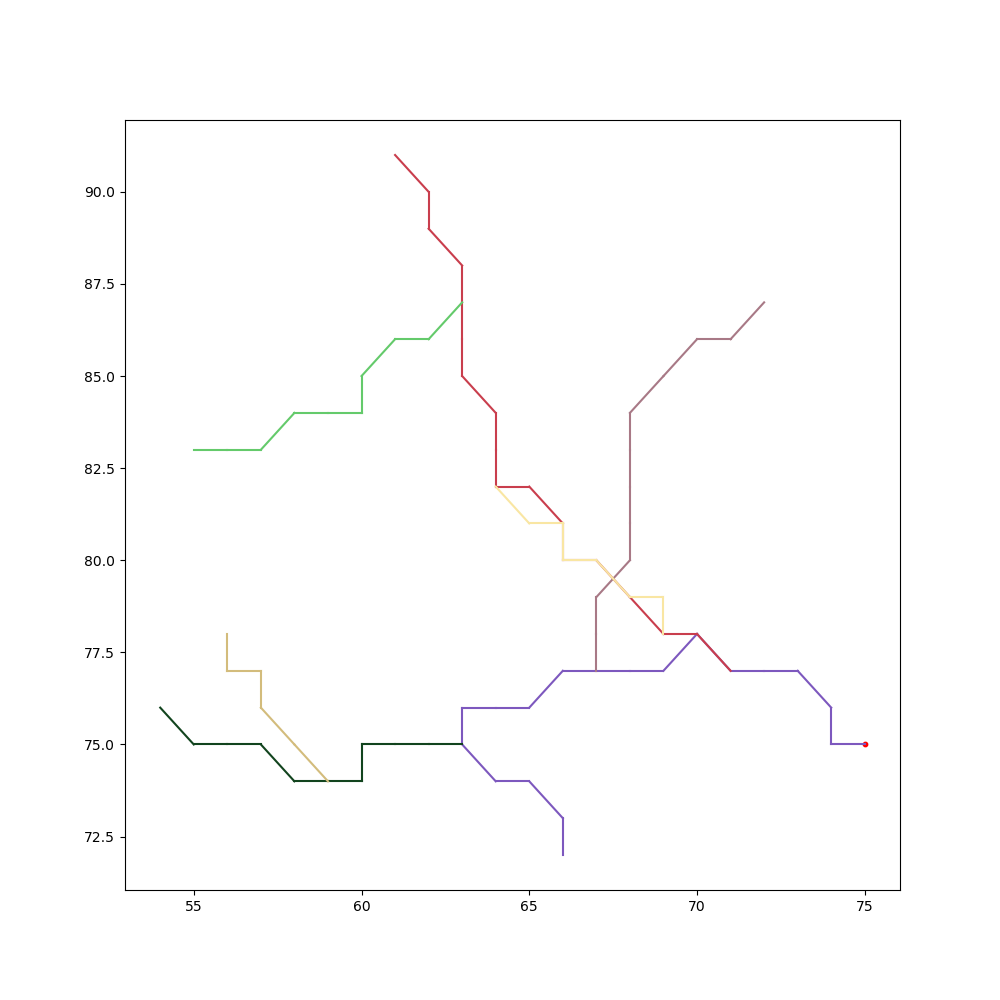

In [73]:
fig, ax = plt.subplots(figsize=(10, 10))
# ax.imshow(img.permute(1,2,3,0).amax(0))
# ax.set_axis_off()

for path in paths:
    c = np.random.rand(3)
    # Draw lines between consecutive points in the path
    for j in range(len(path) - 1):
        y0, x0 = int(np.round(path[j][1])), int(np.round(path[j][2]))
        y1, x1 = int(np.round(path[j+1][1])), int(np.round(path[j+1][2]))
        ax.plot([x0,x1], [y0, y1], color=c)
ax.scatter(np.round(paths[0][0,2]), np.round(paths[0][0,1]), color='red', s=10)  # Mark the start point

In [74]:
path_origins = np.array([p[0][:3] for p in paths])
sections = {}
# divide each path wherever it intersects with the origin of other paths
# create a new section for each segment of the path
for path in paths:
    intersections = [0] + [i+1 for i, point in enumerate(path[1:]) if point[:3] in path_origins]
    if len(intersections) > 1:
        sections |= {len(sections) + i: path[intersections[i]:intersections[i+1]+1] for i in range(len(intersections)-1)}
        if intersections[-1] != len(path) - 1:
            sections[len(sections)] = path[intersections[-1]:]  # Add the last segment
    else:
        sections[len(sections)] = path


In [75]:
divided_paths = [sections[i] for i in sections.keys()]

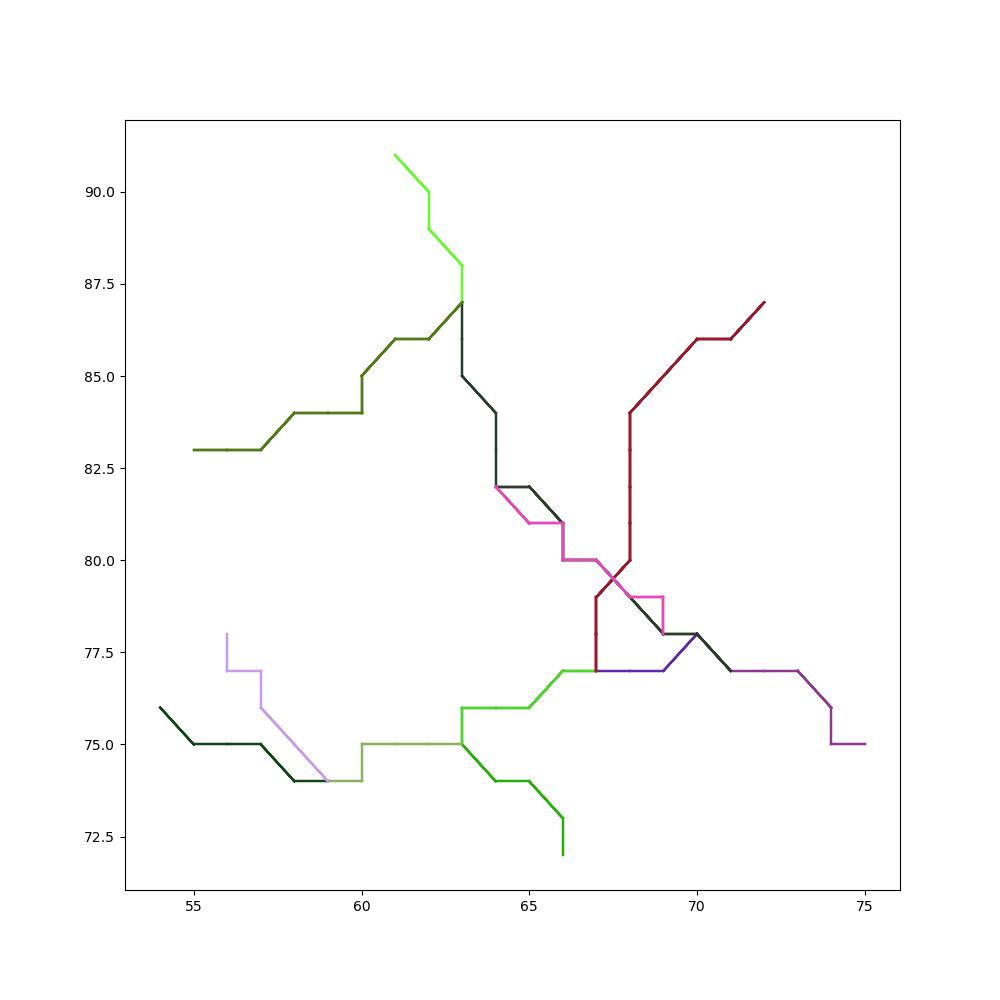

In [76]:
fig, ax = plt.subplots(figsize=(10, 10))
# ax.imshow(img.permute(1,2,3,0).amax(0))
# ax.set_axis_off()

for path in divided_paths:
    c = np.random.rand(3)
    for point in path:
        # Draw lines between consecutive points in the path
        for j in range(len(path) - 1):
            y0, x0 = int(np.round(path[j][1])), int(np.round(path[j][2]))
            y1, x1 = int(np.round(path[j+1][1])), int(np.round(path[j+1][2]))
            ax.plot([x0,x1], [y0, y1], color=c)

In [77]:
sections = split_paths_into_sections(paths)
stream_lengths, section_graph = get_section_stream_lengths(sections)


# Glue sections together into streams based on their lengths
streams = {}
# list all sections in descending order of their lengths
section_ids_sorted = sorted(stream_lengths.keys(), key=lambda x: stream_lengths[x], reverse=True)
# start with the longest stream
while section_ids_sorted:
    streams[section_ids_sorted[0]] = glue_streams_together(section_ids_sorted[0], section_graph, stream_lengths)
    # remove the sections that have been glued together
    for section in streams[section_ids_sorted[0]]:
        if section in section_ids_sorted:
            section_ids_sorted.remove(section)

# restitched_sections = {i: np.concatenate([sections[section_id] for section_id in streams[i]]) for i in streams.keys()}
restitched_sections = {}
for i in streams.keys():
    restitched_section = np.concatenate([sections[section_id] for section_id in streams[i]])
    # remove duplicate points, keep order of first occurrence
    restitched_section, indices = np.unique(restitched_section, axis=0, return_index=True)
    order = np.argsort(indices)
    restitched_section = restitched_section[order]
    restitched_sections[i] = restitched_section


TypeError: sum() received an invalid combination of arguments - got (numpy.ndarray, dim=int), but expected one of:
 * (Tensor input, *, torch.dtype dtype = None)
 * (Tensor input, tuple of ints dim, bool keepdim = False, *, torch.dtype dtype = None, Tensor out = None)
 * (Tensor input, tuple of names dim, bool keepdim = False, *, torch.dtype dtype = None, Tensor out = None)


In [39]:
new_streams = [restitched_sections[i] for i in restitched_sections.keys()]

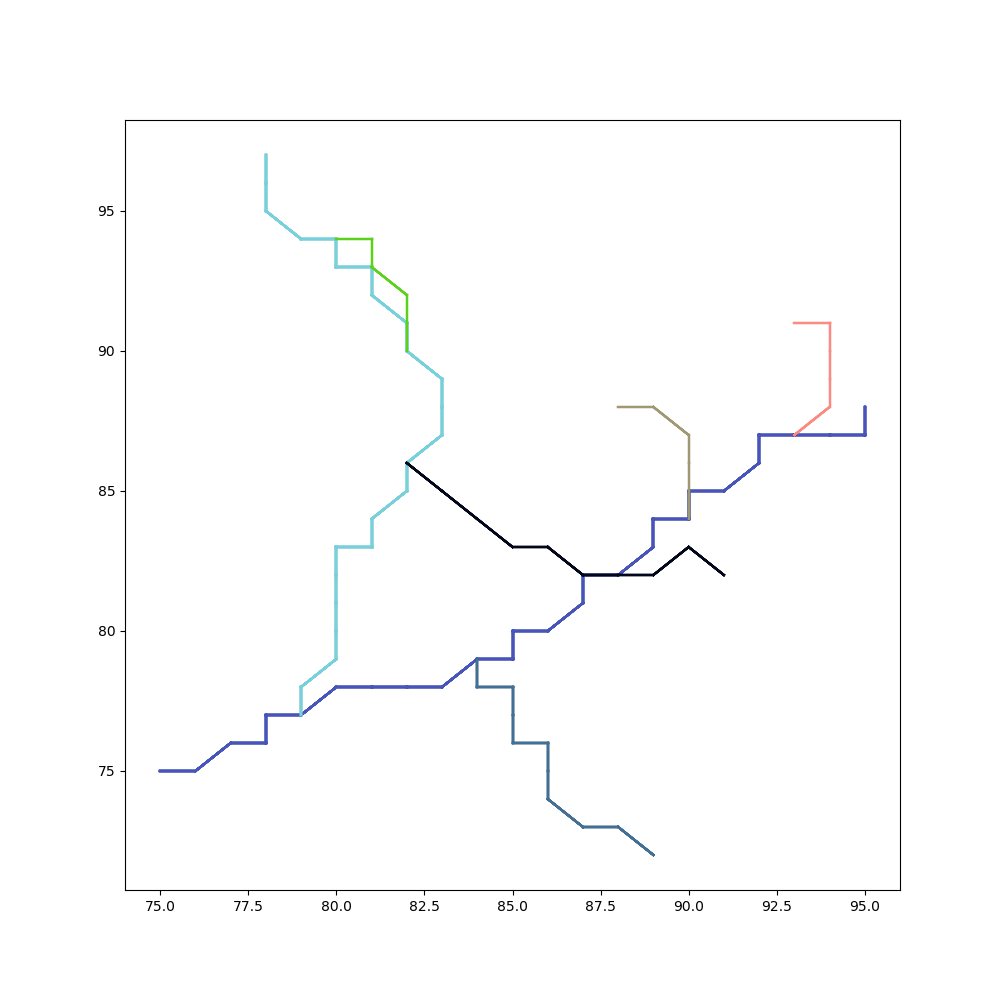

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))
# ax.imshow(img.permute(1,2,3,0).amax(0))
# ax.set_axis_off()

for path in new_streams:
    c = np.random.rand(3)
    for point in path:
        # Draw lines between consecutive points in the path
        for j in range(len(path) - 1):
            y0, x0 = int(np.round(path[j][1])), int(np.round(path[j][2]))
            y1, x1 = int(np.round(path[j+1][1])), int(np.round(path[j+1][2]))
            ax.plot([x0,x1], [y0, y1], color=c)

In [9]:
def plot_sections(sections):
    # Create a DataFrame for plotting
    data = []
    # Iterate through the sections dictionary
    for section_id, section_data in sections.items():
        # flatten the section into one list of consecutive points instead of segments (point pairs)
        for i,segment in enumerate(section_data):
            point = segment[0] 
            data.append([section_id, point[0].item(), point[1].item(), point[2].item()])
            if i == len(section_data)-1:
                point = segment[1]
                data.append([section_id, point[0].item(), point[1].item(), point[2].item()])
    df_sections = pd.DataFrame(data, columns=["section", "x", "y", "z"])

    fig = px.line_3d(df_sections, x="x", y="y", z="z", color='section', )
    fig.update_layout(scene_aspectmode='data')
    fig.show()

In [40]:
# generate a neuron tree with branching structure
estimated_shape = torch.tensor([150.0, 150.0, 150.0])
target_path_len = 10.0
kappa = 20.0
num_branches = 1
rng = np.random.default_rng()
swc_list = generate.make_swc_list(
    size=estimated_shape,
    length=target_path_len,
    step_size=1.0,
    kappa=kappa,
    num_branches=num_branches,
    rng=rng
)


In [41]:
# plot the tree structure using plotly.express
sections, section_graph = load.parse_swc(swc_list)
plot_sections(sections)

In [42]:
for i in range(3):
    print(len(sections[list(sections.keys())[i]][:, 0, :3]))

40
11
52


In [43]:
restructured_sections = tree.restructure_neuron_tree(torch.tensor(swc_list), input_type="swc")
restructured_sections = {k: torch.stack((v[:-1], v[1:]), dim=1) for k, v in restructured_sections.items()}
plot_sections(restructured_sections)